<h1 align='center'> Practical Lab 3</h1>

- Name: Abdul Bari Mohammed
- Student ID: 8985877

# Reducing the data

In [1]:
import os
import shutil
import random

In [2]:
original_dataset_dir = r"C:\Users\User\Dogs_vs_Cats_Project\data\dogs_vs_cats_images_lab3\train"
base_dir = r"C:\Users\User\Dogs_vs_Cats_Project\data\dogs_vs_cats_reduced"

os.makedirs(base_dir, exist_ok=True)

for split in ["train", "validation", "test"]:
    split_dir = os.path.join(base_dir, split)
    os.makedirs(split_dir, exist_ok=True)
    
    for category in ["cats", "dogs"]:
        os.makedirs(os.path.join(split_dir, category), exist_ok=True)

def create_subset(source_dir, target_dir, category, count):
    filenames = [f for f in os.listdir(source_dir) if f.startswith(category)]
    available_files = len(filenames)
    # adjusting counts to the number of variables
    if available_files < count:
        print(f"Warning: Only {available_files} {category} images available. Reducing the count.")
        count = available_files 
    selected_files = random.sample(filenames, count)
    
    for file in selected_files:
        shutil.move(os.path.join(source_dir, file), os.path.join(target_dir, file))
# moving images to training, testing and validation
create_subset(original_dataset_dir, os.path.join(base_dir, "train/cats"), "cat", 1000)
create_subset(original_dataset_dir, os.path.join(base_dir, "train/dogs"), "dog", 1000)
create_subset(original_dataset_dir, os.path.join(base_dir, "validation/cats"), "cat", 500)
create_subset(original_dataset_dir, os.path.join(base_dir, "validation/dogs"), "dog", 500)
create_subset(original_dataset_dir, os.path.join(base_dir, "test/cats"), "cat", 1000)
create_subset(original_dataset_dir, os.path.join(base_dir, "test/dogs"), "dog", 1000)

print("dataset is been reduced to 5k images successfully")


dataset is been reduced to 5k images successfully


### While reducing I have splitted the data into training, test and validation sets.

***

# Exploration Data Analysis(EDA)

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
base_dir = r"C:\Users\User\Dogs_vs_Cats_Project\data\dogs_vs_cats_reduced"

# here i have created ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)

validation_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "validation"),
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)
print("data is been loaded")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
data is been loaded


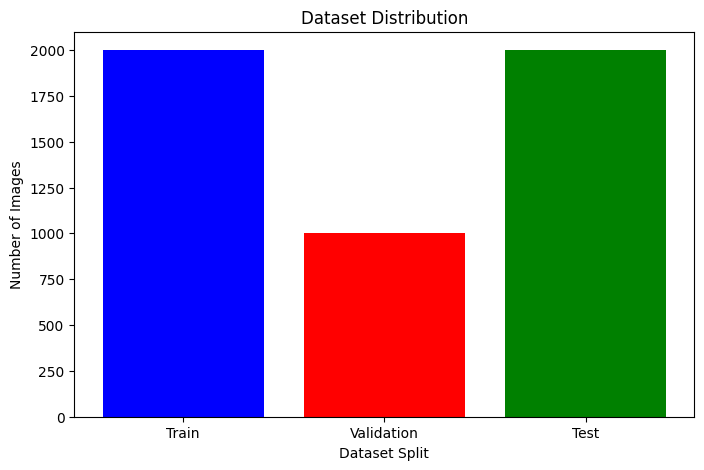

Train Images: 2000, Validation Images: 1000, Test Images: 2000


In [5]:
import matplotlib.pyplot as plt

num_train = train_generator.samples
num_val = validation_generator.samples
num_test = test_generator.samples

labels = ["Train", "Validation", "Test"]
values = [num_train, num_val, num_test]

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=["blue", "red", "green"])
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()

print(f"Train Images: {num_train}, Validation Images: {num_val}, Test Images: {num_test}")

### Above is the bar chart in which I have displayed the split of dataset into test, train and validation dataset. As we can see 2000 is in training set, 2000 in test and 1000 in validation set.

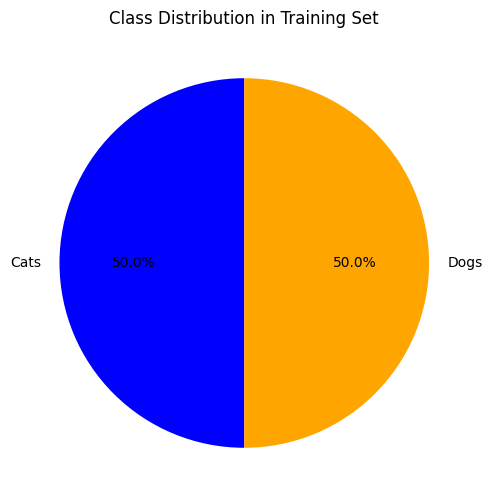

Cats: 1000, Dogs: 1000


In [6]:
train_labels = train_generator.classes
cat_count = sum(train_labels == 0)
dog_count = sum(train_labels == 1)

plt.figure(figsize=(6, 6))
plt.pie([cat_count, dog_count], labels=["Cats", "Dogs"], autopct='%1.1f%%', startangle=90, colors=["blue", "orange"])
plt.title("Class Distribution in Training Set")
plt.show()

print(f"Cats: {cat_count}, Dogs: {dog_count}")

### The pie chart I have displayed above shows the split of two classes (one for dogs and one for cats) in training set. As we can see 50% are cats and 50% are dogs which means I have splitted the data equally in the training set.

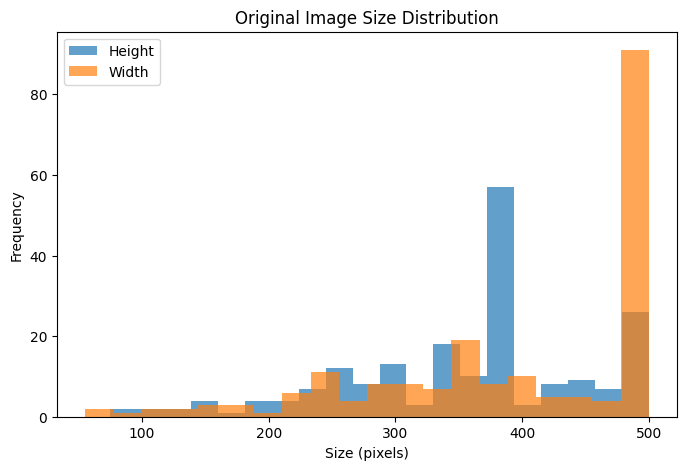

In [7]:
import cv2
import numpy as np

image_sizes = []

# considered the sample of 100 images
for category in ["train/dogs", "train/cats"]:
    category_path = os.path.join(base_dir, category)
    image_files = os.listdir(category_path)[:100] 
    
    for image_file in image_files:
        img_path = os.path.join(category_path, image_file)
        img = cv2.imread(img_path)
        if img is not None:
            image_sizes.append(img.shape[:2]) 

# here i have converted to Numpy and plotted histogram.
image_sizes = np.array(image_sizes)
plt.figure(figsize=(8, 5))
plt.hist(image_sizes[:, 0], bins=20, alpha=0.7, label="Height")
plt.hist(image_sizes[:, 1], bins=20, alpha=0.7, label="Width")
plt.xlabel("Size (pixels)")
plt.ylabel("Frequency")
plt.title("Original Image Size Distribution")
plt.legend()
plt.show()

### I have displayed above histogram for displaying pixels of the images. considered size (height and width) for the pixels from the sample of 100 images.

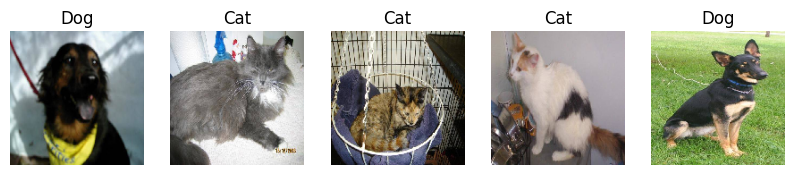

In [8]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title("Dog" if labels[i] == 1 else "Cat")
plt.show()

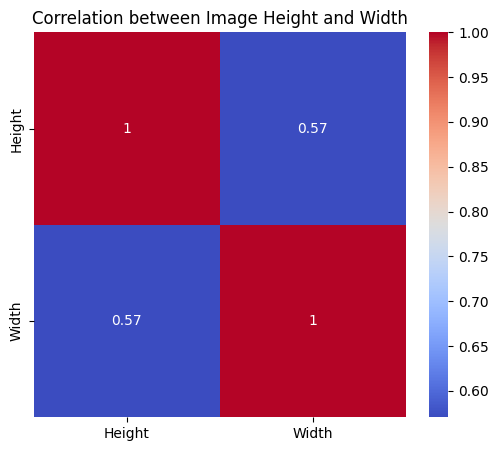

In [9]:
import seaborn as sns

# this code calculates the correlation between height and widht of the images.
correlation_matrix = np.corrcoef(image_sizes[:, 0], image_sizes[:, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=['Height', 'Width'], yticklabels=['Height', 'Width'])
plt.title("Correlation between Image Height and Width")
plt.show()

***

# Comparison between Neural Network and Fine-Tune VGG16

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
 
 def create_nn_model(input_shape):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid') 
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# here i have created the model
input_shape = (150, 150, 3) 
nn_model = create_nn_model(input_shape)
nn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 67500)             0         
                                                                 
 dense (Dense)               (None, 512)               34560512  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 257       
                                                                 
Total params: 34,692,097
Trainable params: 34,692,097
No

### I have used sequential neural network with three layers. first layer with ***512*** units which helps regularize the model and prevents the overfitting, the second layer ***(relu)*** with ***256*** units will be used in the hidden layers and the third layer ***(sigmoid)*** with ***1*** unit which is used in the output layer for making the binary predictions. WE can see the model has total of ***34,692,097*** trainable parameters.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# excluded the classification layer
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# here I have freezed the base layers
for layer in vgg_base.layers:
    layer.trainable = False

# here I have customized the classification layers on top of the model.
x = GlobalAveragePooling2D()(vgg_base.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x)

vgg_model = Model(inputs=vgg_base.input, outputs=x)
vgg_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
vgg_model.summary()

58889256/58889256 [==============================] - 5s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                              

In [ ]:
checkpoint_callback = ModelCheckpoint(
    "best_model.h5", 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min', 
    verbose=1
)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

### The code I wrote above defines the model checkpoint callback for saving the best model based on accuracy of validation and defined early stopping for preventing the overffitting.

In [ ]:
# training the sequential neural network model.
history_nn = nn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/50
63/63 [==============================] - ETA: 0s - loss: 12.3601 - accuracy: 0.4845
Epoch 1: val_loss improved from inf to 0.68906, saving model to best_model.h5
63/63 [==============================] - 26s 395ms/step - loss: 12.3601 - accuracy: 0.4845 - val_loss: 0.6891 - val_accuracy: 0.5430
Epoch 2/50
63/63 [==============================] - ETA: 0s - loss: 0.7011 - accuracy: 0.5010
Epoch 2: val_loss did not improve from 0.68906
63/63 [==============================] - 16s 256ms/step - loss: 0.7011 - accuracy: 0.5010 - val_loss: 0.6931 - val_accuracy: 0.5150
Epoch 3/50
63/63 [==============================] - ETA: 0s - loss: 0.6952 - accuracy: 0.5040
Epoch 3: val_loss did not improve from 0.68906
63/63 [==============================] - 16s 252ms/step - loss: 0.6952 - accuracy: 0.5040 - val_loss: 0.6935 - val_accuracy: 0.5060
Epoch 4/50
63/63 [==============================] - ETA: 0s - loss: 0.6928 - accuracy: 0.5025
Epoch 4: val_loss did not improve from 0.68906
63/63 [

In [19]:
# training the VGG16 model.
history_vgg = vgg_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/50
63/63 [==============================] - ETA: 0s - loss: 0.5220 - accuracy: 0.7255
Epoch 1: val_loss improved from 0.68906 to 0.37076, saving model to best_model.h5
63/63 [==============================] - 396s 6s/step - loss: 0.5220 - accuracy: 0.7255 - val_loss: 0.3708 - val_accuracy: 0.8450
Epoch 2/50
63/63 [==============================] - ETA: 0s - loss: 0.3548 - accuracy: 0.8440
Epoch 2: val_loss improved from 0.37076 to 0.32119, saving model to best_model.h5
63/63 [==============================] - 420s 7s/step - loss: 0.3548 - accuracy: 0.8440 - val_loss: 0.3212 - val_accuracy: 0.8600
Epoch 3/50
63/63 [==============================] - ETA: 0s - loss: 0.3088 - accuracy: 0.8625
Epoch 3: val_loss did not improve from 0.32119
63/63 [==============================] - 408s 7s/step - loss: 0.3088 - accuracy: 0.8625 - val_loss: 0.3226 - val_accuracy: 0.8420
Epoch 4/50
63/63 [==============================] - ETA: 0s - loss: 0.2939 - accuracy: 0.8780
Epoch 4: val_loss impro

In [ ]:
from tensorflow.keras.models import load_model

# this code loades the best model which was saved during training.
best_nn_model = load_model("best_model.h5")
best_vgg_model = load_model("best_model.h5")

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# here I have evaluated the best neural network model.
y_true = test_generator.classes
y_pred_nn = best_nn_model.predict(test_generator)
# this code converts the probabilities to binary values.
y_pred_nn = (y_pred_nn > 0.5).astype(int) 

# here I have evaluated the best VGG16 model.
y_pred_vgg = best_vgg_model.predict(test_generator)
y_pred_vgg = (y_pred_vgg > 0.5).astype(int)

print("Classification Report - Sequential Neural Network:")
print(classification_report(y_true, y_pred_nn))

print("Classification Report - VGG16:")
print(classification_report(y_true, y_pred_vgg))

63/63 [==============================] - 369s 6s/step
Classification Report - Sequential Neural Network:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1000
           1       0.89      0.88      0.88      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.88      2000
weighted avg       0.89      0.89      0.88      2000

Classification Report - VGG16:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1000
           1       0.89      0.88      0.88      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.88      2000
weighted avg       0.89      0.89      0.88      2000



In [26]:
cm_nn = confusion_matrix(y_true, y_pred_nn)
cm_vgg = confusion_matrix(y_true, y_pred_vgg)

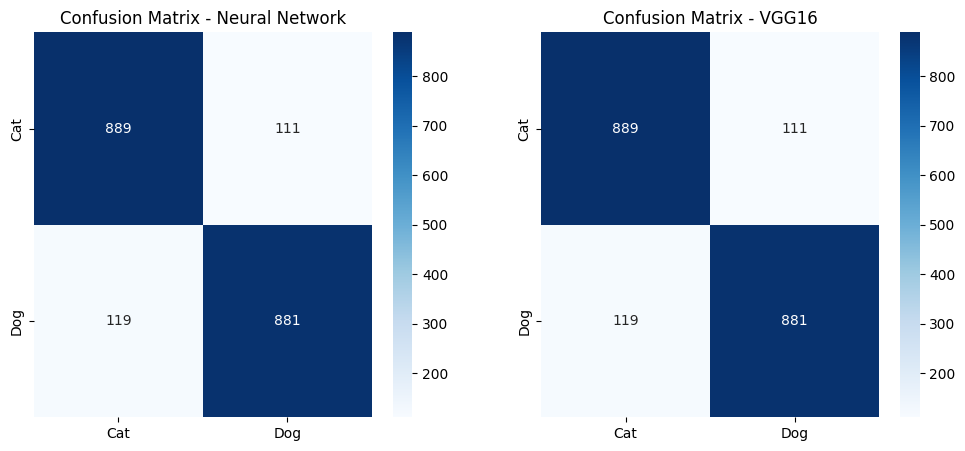

In [27]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
plt.title("Confusion Matrix - Neural Network")

plt.subplot(1, 2, 2)
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
plt.title("Confusion Matrix - VGG16")
plt.show()

In [28]:
precision_nn, recall_nn, _ = precision_recall_curve(y_true, y_pred_nn)
precision_vgg, recall_vgg, _ = precision_recall_curve(y_true, y_pred_vgg)

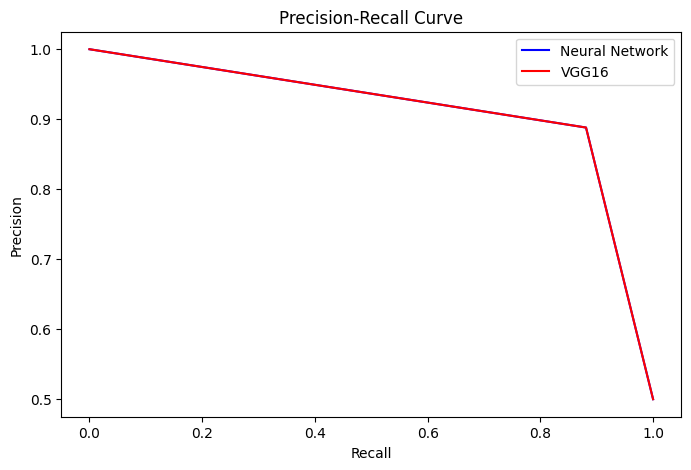

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(recall_nn, precision_nn, label="Neural Network", color='blue')
plt.plot(recall_vgg, precision_vgg, label="VGG16", color='red')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

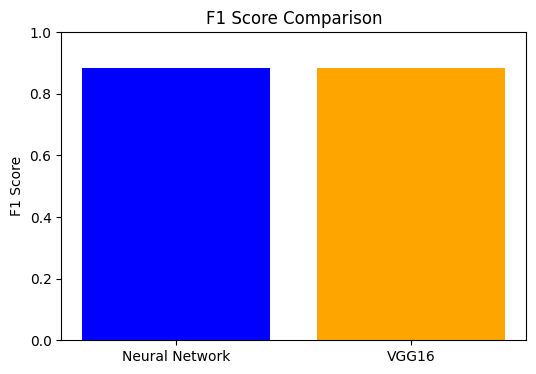

In [34]:
models = ['Neural Network', 'VGG16']
f1_scores = [f1_nn, f1_vgg]

plt.figure(figsize=(6, 4))
plt.bar(models, f1_scores, color=['blue', 'orange'])
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.title("F1 Score Comparison")
plt.show()

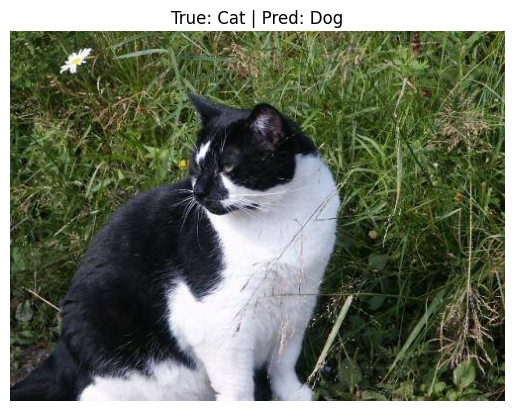

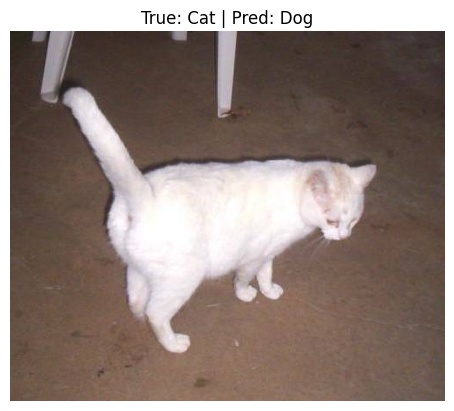

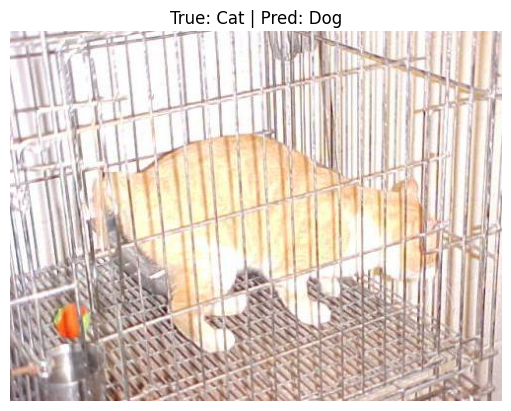

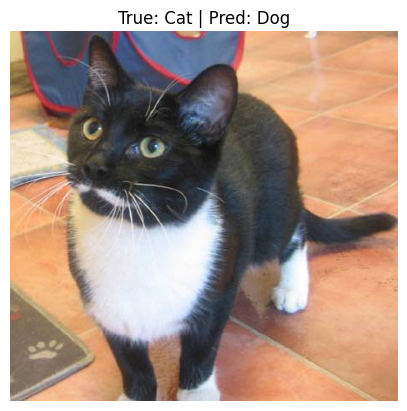

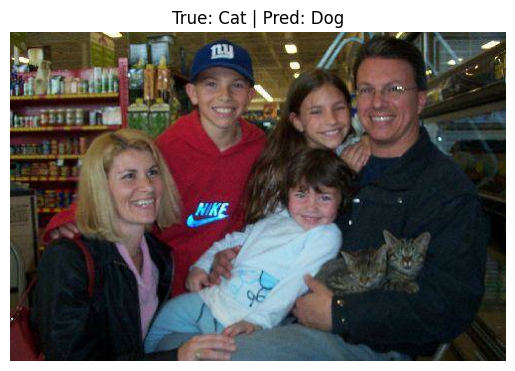

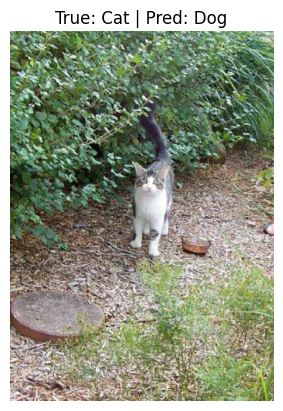

In [36]:
# this code is for getting the incorrect predictions.
incorrect_predictions = []
for i, (true_label, pred_nn, pred_vgg) in enumerate(zip(y_true, y_pred_nn, y_pred_vgg)):
    if true_label != pred_nn: 
        incorrect_predictions.append((i, true_label, pred_nn))
    elif true_label != pred_vgg:  
        incorrect_predictions.append((i, true_label, pred_vgg))

# here I have displayed some incorrect predictions.
for idx, true, pred in incorrect_predictions[:6]: 
    image_path = test_generator.filenames[idx]
    image = plt.imread(os.path.join(base_dir, "test", image_path))
    plt.imshow(image)
    plt.title(f"True: {'Dog' if true == 1 else 'Cat'} | Pred: {'Dog' if pred == 1 else 'Cat'}")
    plt.axis('off')
    plt.show()

### I have displayed some samples in which both the models failed to predict correctly.